In [2]:
import pandas as pd
import numpy as np

C:\Users\Lenovo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## TASK 1

In [3]:
# Loading the csv file using pandas

df = pd.read_csv('Housing.csv')

In [4]:
# Displaying the first 10 rows

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
# Checking the number of rows and columns

rows, columns = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 545
Number of columns: 13


In [6]:
# Identifying the target and features

target = 'price'

# All the columns except target are features
features = [col for col in df.columns if col != target]

print(f"Target Variable (What we want to predict): '{target}'")
print(f"Feature Variables (Predictors): {features}")

Target Variable (What we want to predict): 'price'
Feature Variables (Predictors): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## TASK 2 - DATA CLEANING

In [8]:
# If there are any missing values, drop that meaning value and replace it with the median

df = df.dropna(subset=['price'])
df = df.fillna(df.median(numeric_only=True))

In [9]:
# Removing duplicate rows

initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]
print(f"Removed {initial_rows - final_rows} duplicate rows.")

Removed 0 duplicate rows.


In [10]:
# Checking for all the column's data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [11]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [12]:
df_cleaned = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [13]:
print(df_cleaned.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [14]:
print(df_cleaned.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

## TASK 3 - MODEL BUILDING

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
X = df_cleaned.drop(columns=['price'])  # Features
y = df_cleaned['price']                 # Target 

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [18]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_lr = lr_model.predict(X_test)

In [20]:
#Train a second model — Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

In [21]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Calculate metrics
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, y_pred_lr)
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, y_pred_rf)

In [22]:
performance_comparison = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Score (Accuracy)'],
    'Linear Regression': [f"${lr_mae:,.2f}", f"${lr_rmse:,.2f}", f"{lr_r2:.4f}"],
    'Random Forest': [f"${rf_mae:,.2f}", f"${rf_rmse:,.2f}", f"{rf_r2:.4f}"]
})

print("--- MODEL PERFORMANCE COMPARISON ---")
print(performance_comparison.to_string(index=False))

--- MODEL PERFORMANCE COMPARISON ---
                        Metric Linear Regression Random Forest
     Mean Absolute Error (MAE)       $970,043.40 $1,021,546.04
Root Mean Squared Error (RMSE)     $1,324,506.96 $1,400,565.97
           R² Score (Accuracy)            0.6529        0.6119


## TASK 4 - VISUALIZATION

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
sns.set_theme(style="whitegrid")

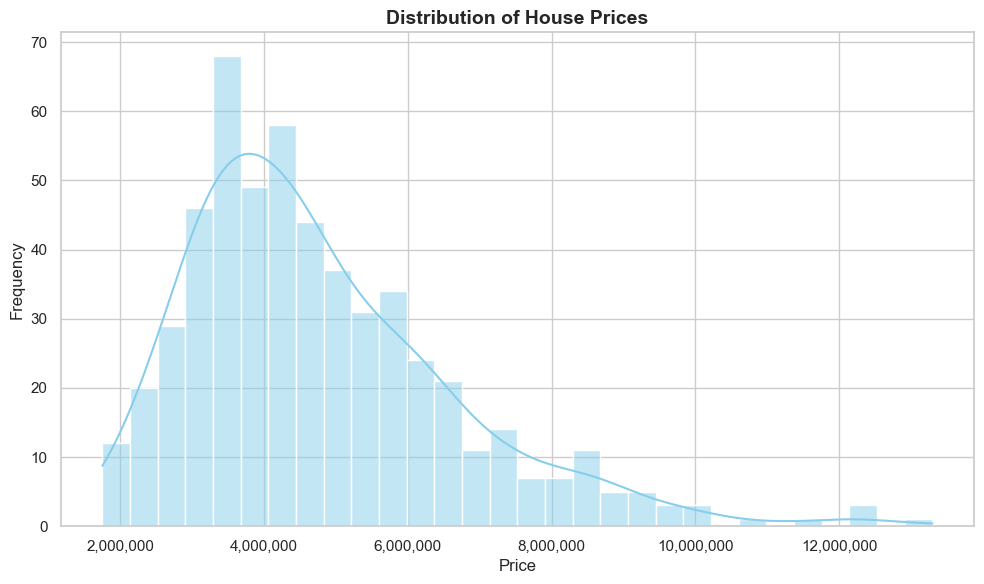

In [28]:
# Histogram showing the distribution of house prices
plt.figure(figsize=(10, 6))
# Using df from Task 1 (original unencoded data works best for a simple price distribution)
sns.histplot(df['price'], kde=True, color='skyblue', bins=30)

plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Format x-axis with thousands/millions separators for readability
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

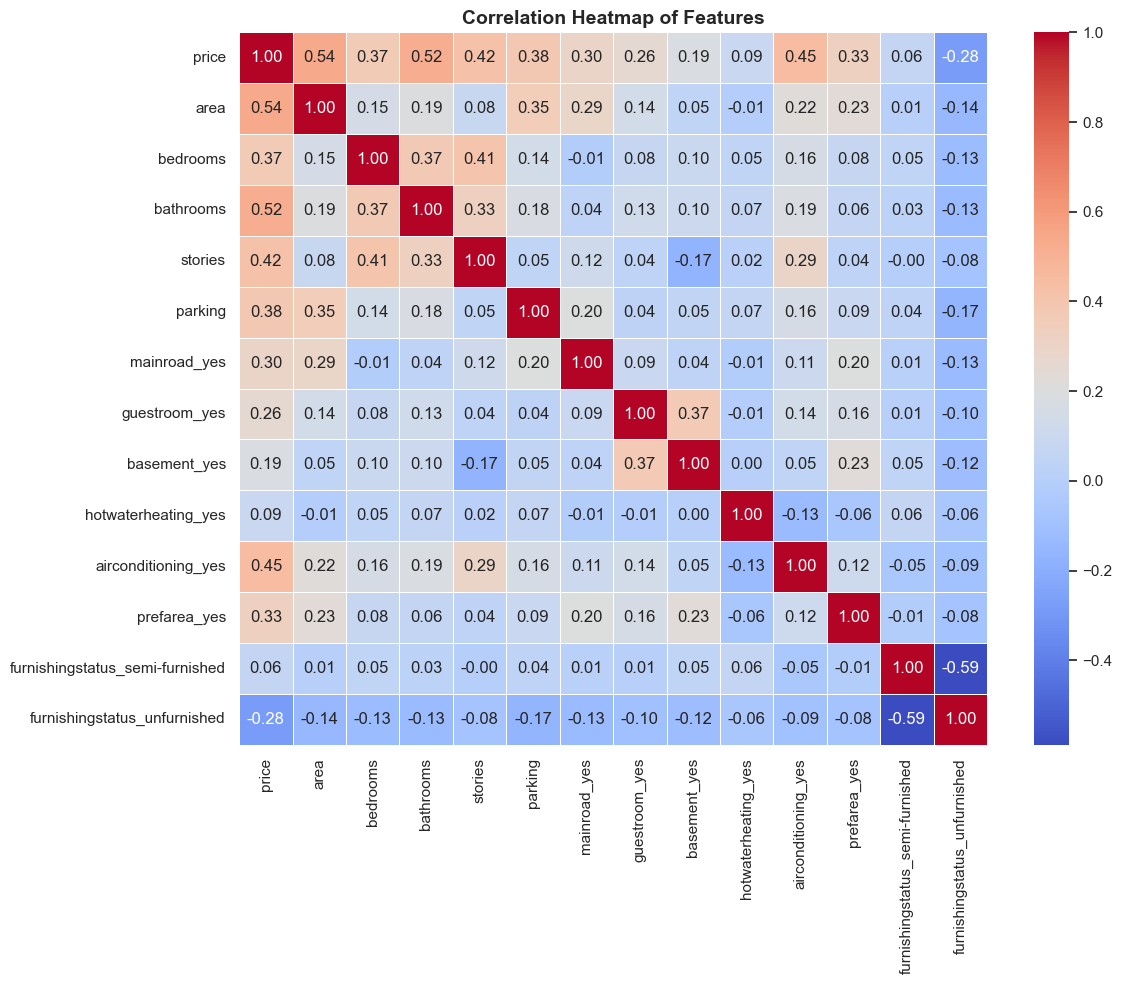

In [29]:
# Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12, 10))

# Compute correlation matrix on the cleaned numeric dataset from Task 2
# We focus on how features relate to each other and specifically to 'price'
correlation_matrix = df_cleaned.corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

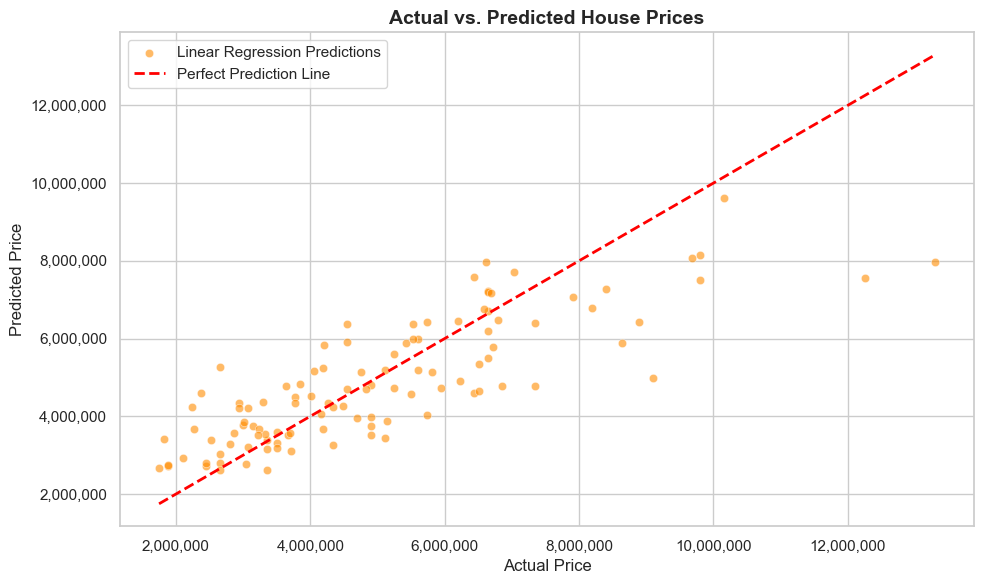

In [30]:
# Actual vs. Predicted Price Scatter Plot (Model Evaluation)

plt.figure(figsize=(10, 6))

# Plotting the predictions from the Linear Regression model built in Task 3
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='darkorange', label='Linear Regression Predictions')

# Plot a perfect diagonal reference line (where Actual equals Predicted)
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)

# Format axes with commas
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend()
plt.tight_layout()
plt.show()

## TASK 5 - INSIGHTS & SUMMARY

#### Based on our exploratory data analysis and model building, the structural size (area) along with basic configurations like the number of bathrooms and stories exert the strongest statistical influence on house prices. 
#### Our baseline predictive models captured the underlying valuation trends reasonably well, achieving a solid R2 score that indicates our chosen features explain a significant portion of price variance, though typical predictions still deviate from actual sale prices by a standard margin (tracked via MAE). 
#### A surprising observation in the data was that qualitative factors—such as proximity to a mainroad or the presence of a basement—often carried distinct valuation premiums comparable to adding an extra bedroom. For a real estate business leveraging these findings, our primary recommendation is to prioritize property acquisitions focusing heavily on maximum plot square footage (area) and multi-story layouts, while viewing features like premium furnishing status as secondary, easily modifiable value-adders rather than core drivers of initial property worth.